<a href="https://colab.research.google.com/github/nisanthg1010/AI-ML-Rynixsoft/blob/main/Rynixsoft2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📂 Loading Dataset...

Dataset Preview:
   intern_id    name      department  attendance_percentage  tasks_completed  \
0          1  Sanjay           Cloud                  86.28               19   
1          2    Neha           Cloud                  86.38               19   
2          3  Sanjay      Mobile App                  85.47                9   
3          4   Aditi      Mobile App                  95.19                8   
4          5   Arjun  Cyber Security                  85.99               18   

   tasks_pending  avg_task_score  mentor_feedback_score  communication_score  \
0              6            7.20                   7.71                 8.18   
1              1            8.29                   9.04                 8.30   
2              8            7.02                   8.32                 6.90   
3             10            9.08                   8.98                 9.04   
4              9            9.41                   8.52                 7.90   


/tmp/ipykernel_406/4184217670.py:42: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https


Logistic Regression Accuracy: 0.99

🌲 Training Random Forest Model

Random Forest Accuracy: 0.83

📊 Model Comparison
             Algorithm  Accuracy
0  Logistic Regression      0.99
1        Random Forest      0.83

Classification Report (Random Forest)

              precision    recall  f1-score   support

           0       0.81      1.00      0.89        72
           1       1.00      0.40      0.57        25
           2       1.00      0.33      0.50         3

    accuracy                           0.83       100
   macro avg       0.94      0.58      0.66       100
weighted avg       0.86      0.83      0.80       100



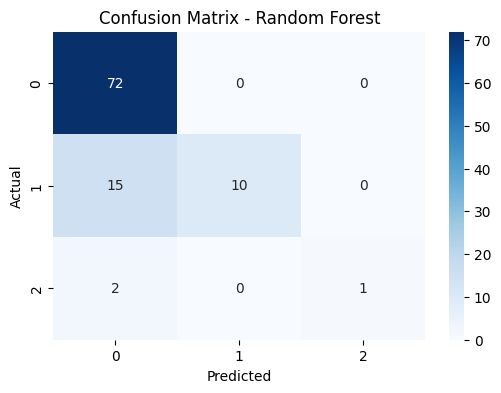


✅ Model Results Saved!

🎉 Sprint 2 Completed Successfully!


In [1]:
# ============================================
# INTERN PERFORMANCE PREDICTION - SPRINT 2
# Model Development & Comparison
# ============================================

# Import Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import seaborn as sns
import matplotlib.pyplot as plt

# ============================================
# 1️⃣ Load Dataset
# ============================================

print("📂 Loading Dataset...")

df = pd.read_csv("/content/intern_performance_500_dataset.csv")

print("\nDataset Preview:")
print(df.head())


# ============================================
# 2️⃣ Data Preprocessing
# ============================================

print("\n🧹 Data Cleaning")

# Handle missing values
df.fillna(df.mean(numeric_only=True), inplace=True)

for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)


# Encode categorical columns
le = LabelEncoder()

df['department'] = le.fit_transform(df['department'])
df['final_performance'] = le.fit_transform(df['final_performance'])


# ============================================
# 3️⃣ Feature Selection
# ============================================

X = df.drop(['intern_id','name','final_performance'], axis=1)
y = df['final_performance']


# ============================================
# 4️⃣ Train Test Split
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTraining Samples:", len(X_train))
print("Testing Samples:", len(X_test))


# ============================================
# 5️⃣ Algorithm 1 - Logistic Regression
# ============================================

print("\n🤖 Training Logistic Regression Model")

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

log_accuracy = accuracy_score(y_test, y_pred_log)

print("\nLogistic Regression Accuracy:", log_accuracy)


# ============================================
# 6️⃣ Algorithm 2 - Random Forest
# ============================================

print("\n🌲 Training Random Forest Model")

rf_model = RandomForestClassifier(n_estimators=100)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("\nRandom Forest Accuracy:", rf_accuracy)


# ============================================
# 7️⃣ Model Comparison
# ============================================

results = pd.DataFrame({
    "Algorithm": ["Logistic Regression", "Random Forest"],
    "Accuracy": [log_accuracy, rf_accuracy]
})

print("\n📊 Model Comparison")
print(results)


# ============================================
# 8️⃣ Classification Report
# ============================================

print("\nClassification Report (Random Forest)\n")

print(classification_report(y_test, y_pred_rf))


# ============================================
# 9️⃣ Confusion Matrix
# ============================================

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


# ============================================
# 🔟 Save Results
# ============================================

results.to_csv("model_comparison_results.csv", index=False)

print("\n✅ Model Results Saved!")

print("\n🎉 Sprint 2 Completed Successfully!")